In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('/content/twitter_training.csv', header=None)

# Assign column names
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

# Display first 5 rows
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Classes:")
print(df['Sentiment'].value_counts())

Dataset Shape: (24004, 4)

Column Names:
['ID', 'Entity', 'Sentiment', 'Tweet']

Missing Values:
ID             0
Entity         0
Sentiment      0
Tweet        220
dtype: int64

Sentiment Classes:
Sentiment
Positive      7278
Neutral       6166
Negative      6156
Irrelevant    4404
Name: count, dtype: int64


In [ ]:
# Remove rows where Tweet is missing
df = df.dropna(subset=['Tweet'])

print("Shape after removing missing tweets:", df.shape)
print("Missing tweets:", df['Tweet'].isnull().sum())

Shape after removing missing tweets: (23784, 4)
Missing tweets: 0


In [ ]:
# Keep only Positive, Negative, and Neutral sentiments
df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

print("Shape after removing Irrelevant class:", df.shape)

print("\nSentiment Classes:")
print(df['Sentiment'].value_counts())

Shape after removing Irrelevant class: (19444, 4)

Sentiment Classes:
Sentiment
Positive    7230
Negative    6117
Neutral     6097
Name: count, dtype: int64


In [ ]:
df = df.reset_index(drop=True)

df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

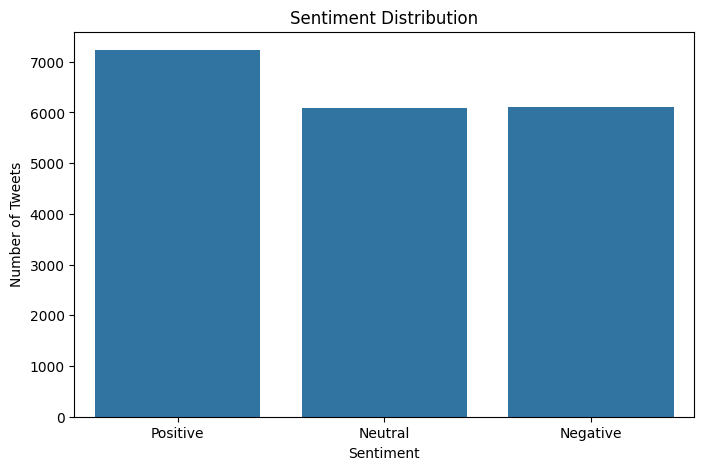

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Sentiment')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

In [ ]:
sentiment_counts = df['Sentiment'].value_counts()

sentiment_percentage = (
    df['Sentiment'].value_counts(normalize=True) * 100
).round(2)

print("Sentiment Counts:")
print(sentiment_counts)

print("\nSentiment Percentage:")
print(sentiment_percentage)

Sentiment Counts:
Sentiment
Positive    7230
Negative    6117
Neutral     6097
Name: count, dtype: int64

Sentiment Percentage:
Sentiment
Positive    37.18
Negative    31.46
Neutral     31.36
Name: proportion, dtype: float64


In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back into text
    return ' '.join(tokens)

In [ ]:
df['Clean_Tweet'] = df['Tweet'].astype(str).apply(preprocess_text)

df[['Tweet', 'Clean_Tweet']].head(10)

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,I am coming to the borders and I will kill you...,coming borders kill
2,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,im coming on borderlands and i will murder you...,im coming borderlands murder
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder
5,im getting into borderlands and i can murder y...,im getting borderlands murder
6,So I spent a few hours making something for fu...,spent hours making something fun dont know hug...
7,So I spent a couple of hours doing something f...,spent couple hours something fun dont know im ...
8,So I spent a few hours doing something for fun...,spent hours something fun dont know im huge bo...
9,So I spent a few hours making something for fu...,spent hours making something fun dont know hug...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

In [ ]:
X = tfidf.fit_transform(df['Clean_Tweet'])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (19444, 10000)


In [ ]:
y = df['Sentiment']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (19444, 10000)
Target shape: (19444,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 15555
Testing samples: 3889


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

In [ ]:
nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes predictions completed!")
print(y_pred_nb[:10])

Naive Bayes predictions completed!
['Neutral' 'Negative' 'Neutral' 'Positive' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Negative' 'Positive']


In [ ]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 84.78 %


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [ ]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression predictions completed!")
print(y_pred_lr[:10])

Logistic Regression predictions completed!
['Neutral' 'Negative' 'Neutral' 'Positive' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Negative' 'Positive']


In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 88.56 %
